# Lecture 17: date_range() and asfreq()
## date_range() — Generating a Custom Date Sequence
- pd.date_range(start=, end=, freq=) generates a DatetimeIndex between two dates
- pd.date_range(start=, periods=n, freq=) generates n dates starting from a point (no end date needed)
- freq='B' → Business days only (skips weekends)
- freq='D'/'W'/'H'/'M' etc. → Daily/Weekly/Hourly/Monthly

In [1]:
import pandas as pd
df = pd.read_csv("../datasets/aapl_no_dates.csv")
df.head()

rng = pd.date_range(start="6-1-2017", end="6-20-2017", freq='B')
rng

DatetimeIndex(['2017-06-01', '2017-06-02', '2017-06-05', '2017-06-06',
               '2017-06-07', '2017-06-08', '2017-06-09', '2017-06-12',
               '2017-06-13', '2017-06-14', '2017-06-15', '2017-06-16',
               '2017-06-19', '2017-06-20'],
              dtype='datetime64[ns]', freq='B')

## Applying a Generated Date Range as an Index
- Useful when a dataset has no date column at all — you can manually generate
  and attach a proper DatetimeIndex, as long as row order matches

In [2]:
df.set_index(rng, inplace=True)
df


,Open,High,Low,Close,Volume
2017-06-01,144.88,145.30,143.10,143.50,14277848
2017-06-02,143.69,144.79,142.72,144.09,21569557
2017-06-05,143.02,143.50,142.41,142.73,24128782
2017-06-06,142.90,144.75,142.90,144.18,19201712
2017-06-07,144.11,145.95,143.37,145.06,21090636
2017-06-08,144.73,145.85,144.38,145.53,19781836
2017-06-09,145.87,146.18,144.82,145.74,24884478
2017-06-12,145.50,148.49,145.44,147.77,25199373
2017-06-13,147.97,149.33,147.33,149.04,20132061
2017-06-14,148.82,150.90,148.57,149.56,23793456


<Axes: >

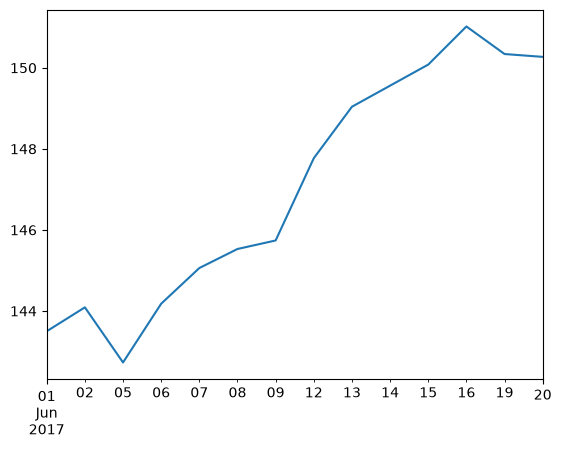

In [3]:
%matplotlib inline
df.Close.plot()

## Date Range Slicing (Without .loc)
- Once the index is a DatetimeIndex, df["start_date":"end_date"] also works directly
  (slicing with colon, similar to .loc but without needing .loc explicitly here)

In [4]:
df["2017-06-01":"2017-06-5"]

,Open,High,Low,Close,Volume
2017-06-01,144.88,145.30,143.10,143.50,14277848
2017-06-02,143.69,144.79,142.72,144.09,21569557
2017-06-05,143.02,143.50,142.41,142.73,24128782


In [5]:
df["2017-06-01":"2017-06-5"].Close.mean()

np.float64(143.44000000000003)

## asfreq() — Changing Frequency WITHOUT Aggregating
- Different from resample(): resample() aggregates (mean/sum) when converting frequency,
  asfreq() just changes the frequency and fills in gaps using a fill method — no calculation
- method='pad' (a.k.a forward fill) → carries the previous value forward into new/missing slots
- Can go to a FINER frequency too (e.g. Daily → Hourly), unlike resample which is mainly for aggregating to coarser frequencies

In [6]:
df.asfreq('D', method='pad')

,Open,High,Low,Close,Volume
2017-06-01,144.88,145.30,143.10,143.50,14277848
2017-06-02,143.69,144.79,142.72,144.09,21569557
2017-06-03,143.69,144.79,142.72,144.09,21569557
2017-06-04,143.69,144.79,142.72,144.09,21569557
2017-06-05,143.02,143.50,142.41,142.73,24128782
2017-06-06,142.90,144.75,142.90,144.18,19201712
2017-06-07,144.11,145.95,143.37,145.06,21090636
2017-06-08,144.73,145.85,144.38,145.53,19781836
2017-06-09,145.87,146.18,144.82,145.74,24884478
2017-06-10,145.87,146.18,144.82,145.74,24884478


In [7]:
df.asfreq('W', method='pad')

,Open,High,Low,Close,Volume
2017-06-04,143.69,144.79,142.72,144.09,21569557
2017-06-11,145.87,146.18,144.82,145.74,24884478
2017-06-18,150.48,151.42,149.95,151.02,20922969


In [8]:
df.asfreq('H', method='pad')

C:\Users\ap504\AppData\Local\Temp\ipykernel_9964\4288472492.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df.asfreq('H', method='pad')


,Open,High,Low,Close,Volume
2017-06-01 00:00:00,144.88,145.30,143.10,143.50,14277848
2017-06-01 01:00:00,144.88,145.30,143.10,143.50,14277848
2017-06-01 02:00:00,144.88,145.30,143.10,143.50,14277848
2017-06-01 03:00:00,144.88,145.30,143.10,143.50,14277848
2017-06-01 04:00:00,144.88,145.30,143.10,143.50,14277848
...,...,...,...,...,...
2017-06-19 20:00:00,151.50,151.74,150.19,150.34,17243748
2017-06-19 21:00:00,151.50,151.74,150.19,150.34,17243748
2017-06-19 22:00:00,151.50,151.74,150.19,150.34,17243748
2017-06-19 23:00:00,151.50,151.74,150.19,150.34,17243748


## Generating Random Data for Practice/Demo Datasets
- np.random.randint(low, high, size) → array of random integers between low (inclusive) and high (exclusive)
- Combined with date_range(), useful for quickly creating dummy time-series data to practice on

In [9]:
rng = pd.date_range(start="1-1-2017", periods=20, freq='B')
rng

DatetimeIndex(['2017-01-02', '2017-01-03', '2017-01-04', '2017-01-05',
               '2017-01-06', '2017-01-09', '2017-01-10', '2017-01-11',
               '2017-01-12', '2017-01-13', '2017-01-16', '2017-01-17',
               '2017-01-18', '2017-01-19', '2017-01-20', '2017-01-23',
               '2017-01-24', '2017-01-25', '2017-01-26', '2017-01-27'],
              dtype='datetime64[ns]', freq='B')

In [10]:
import numpy as np
np.random.randint(1, 10, len(rng))

ts = pd.Series(np.random.randint(1, 10, len(rng)), index=rng)
ts

2017-01-02    7
2017-01-03    2
2017-01-04    5
2017-01-05    2
2017-01-06    2
2017-01-09    3
2017-01-10    7
2017-01-11    2
2017-01-12    2
2017-01-13    8
2017-01-16    1
2017-01-17    2
2017-01-18    3
2017-01-19    6
2017-01-20    6
2017-01-23    9
2017-01-24    3
2017-01-25    1
2017-01-26    6
2017-01-27    1
Freq: B, dtype: int32